### Earthquake PINN Training on Colab GPU
This notebook clones the repository, installs dependencies, and runs the full-scale training.
It also includes optional Hyperparameter Optimization (Optuna).

**Note**: Make sure you have pushed your local changes (`git push origin dev`) before running this.

In [34]:
!nvidia-smi

Mon Feb 16 00:02:04 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [35]:
# Install uv and clean up existing clone
!pip install uv
!rm -rf earthquake_proj
!git clone -b dev --single-branch https://github.com/sattary/earthquake_proj.git
%cd earthquake_proj

Cloning into 'earthquake_proj'...
remote: Enumerating objects: 175, done.
remote: Counting objects: 100% (175/175), done.
remote: Compressing objects: 100% (90/90), done.
remote: Total 175 (delta 64), reused 162 (delta 51), pack-reused 0 (from 0)
Receiving objects: 100% (175/175), 20.23 MiB | 18.28 MiB/s, done.
Resolving deltas: 100% (64/64), done.
/content/earthquake_proj/earthquake_proj/earthquake_proj/earthquake_proj/earthquake_proj


In [36]:
# Sync environment
!uv sync

Using CPython 3.12.12 interpreter at: /usr/bin/python3
Creating virtual environment at: .venv
Resolved 103 packages in 1ms
Prepared 3 packages in 65ms                                              
Installed 97 packages in 429ms                              
 + alembic==1.18.4
 + annotated-doc==0.0.4
 + asttokens==3.0.1
 + certifi==2026.1.4
 + click==8.3.1
 + cloudpickle==3.1.2
 + colorlog==6.10.1
 + comm==0.2.3
 + contourpy==1.3.3
 + cuda-bindings==12.9.4
 + cuda-pathfinder==1.3.4
 + cycler==0.12.1
 + debugpy==1.8.20
 + decorator==5.2.1
 + executing==2.2.1
 + filelock==3.24.0
 + fonttools==4.61.1
 + fsspec==2026.2.0
 + greenlet==3.3.1
 + iniconfig==2.3.0
 + ipykernel==7.2.0
 + ipython==9.10.0
 + ipython-pygments-lexers==1.1.1
 + jedi==0.19.2
 + jinja2==3.1.6
 + joblib==1.5.3
 + jupyter-client==8.8.0
 + jupyter-core==5.9.1
 + kiwisolver==1.4.9
 + llvmlite==0.46.0
 + mako==1.3.10
 + markdown-it-py==4.0.0
 + markupsafe==3.0.3
 + matplotlib==3.10.8
 + matplotlib-inline==0.2.1
 + mdurl==0.1

In [37]:
!ls

checkpoints  docs     notebooks       README.md  tests
data	     main.py  pyproject.toml  src	 uv.lock


In [38]:
import os
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results/tables", exist_ok=True)
os.makedirs("results/figs", exist_ok=True)

# Ensure package initialization for -m calls
if os.path.exists('src'):
    if not os.path.exists('src/__init__.py'):
        open('src/__init__.py', 'a').close()
        print("Initialized 'src' as package.")
elif os.path.exists('earthquake_proj'):
    if not os.path.exists('earthquake_proj/__init__.py'):
        open('earthquake_proj/__init__.py', 'a').close()
        print("Initialized 'earthquake_proj' as package.")

Initialized 'src' as package.


In [41]:
# Step 1: Tune Hyperparameters (Optional - skip if using defaults)
!PYTHONPATH=. uv run python -m src.pipelines.cli tune --trials 50 --epochs 500


Starting Hyperparameter Tuning with Optuna...
[I 2026-02-16 00:03:43,594] A new study created in memory with name: no-name-ff2b83f5-0907-4e47-80f8-09be955d97ae
Using device: cuda
CoordinateTransformer Initialized:
  Bounds (UTM): X[-23763.9, 1477034.3] Y[2676428.4, 4376797.5]
  Scale Factor: 850184.57 meters
Loading Velocity Model from data/Morteza_2023/Vel/Pwave.3D.txt...
Building 3D Interpolator (Nearest for speed/robustness)...
Velocity Model Ready. Depth Range: 0.0-30.0 km
[I 2026-02-16 00:04:06,605] Trial 0 finished with value: 25.52578353881836 and parameters: {'f_tune': 18.97958023478254, 'lr': 0.0006102951619715928, 'w_pde': 0.09675298231503773, 'w_const': 0.015723045620044212, 'w_bc': 0.116314463340464}. Best is trial 0 with value: 25.52578353881836.
Using device: cuda
CoordinateTransformer Initialized:
  Bounds (UTM): X[-23763.9, 1477034.3] Y[2676428.4, 4376797.5]
  Scale Factor: 850184.57 meters
Loading Velocity Model from data/Morteza_2023/Vel/Pwave.3D.txt...
Building 3D In

In [42]:
# Step 2: Final Stabilized Training
!PYTHONPATH=. uv run python -m src.pipelines.cli train --epochs 20000 --n-coll 20000


Loading config from results/tables/best_params.json: {'f_tune': 7.3088420969614205, 'lr': 0.007120453082950846, 'w_pde': 0.00010506921183518398, 'w_const': 4.912311269733572e-05, 'w_bc': 0.03752113097174815}
Using device: cuda
Starting training on 2 GPS files (Dim=3)...
CoordinateTransformer Initialized:
  Bounds (UTM): X[-23763.9, 1477034.3] Y[2676428.4, 4376797.5]
  Scale Factor: 850184.57 meters
Loading Velocity Model from data/Morteza_2023/Vel/Pwave.3D.txt...
Building 3D Interpolator (Nearest for speed/robustness)...
Velocity Model Ready. Depth Range: 0.0-30.0 km
Training PINN:  10% 999/10000 [07:19<1:07:37,  2.22it/s, Loss=0.0003, Dat=0.0000]Model saved to checkpoints/checkpoint_epoch_1000.pth
Training PINN:  20% 1999/10000 [14:39<58:17,  2.29it/s, Loss=0.0002, Dat=0.0000]  Model saved to checkpoints/checkpoint_epoch_2000.pth
Training PINN:  30% 2999/10000 [21:59<51:00,  2.29it/s, Loss=0.0002, Dat=0.0000]  Model saved to checkpoints/checkpoint_epoch_3000.pth
Training PINN:  40% 39

In [43]:
# Step 3: Generate Academic Figure Suite (PDF, SVG, High-Res PNG)
!PYTHONPATH=. uv run python -m src.pipelines.cli results-suite


CoordinateTransformer Initialized:
  Bounds (UTM): X[-23763.9, 1477034.3] Y[2676428.4, 4376797.5]
  Scale Factor: 850184.57 meters
Loading Velocity Model from data/Morteza_2023/Vel/Pwave.3D.txt...
Building 3D Interpolator (Nearest for speed/robustness)...
Velocity Model Ready. Depth Range: 0.0-30.0 km
Loaded Velocity Model Depth Range: 0.0-30.0 km
Saved stress map to results/figs/stress_map_10km.png
Saved velocity map to results/figs/velocity_map_10km.png
Visualization complete. Saved to results/figs/stress_map_10km.png and results/figs/velocity_map_10km.png


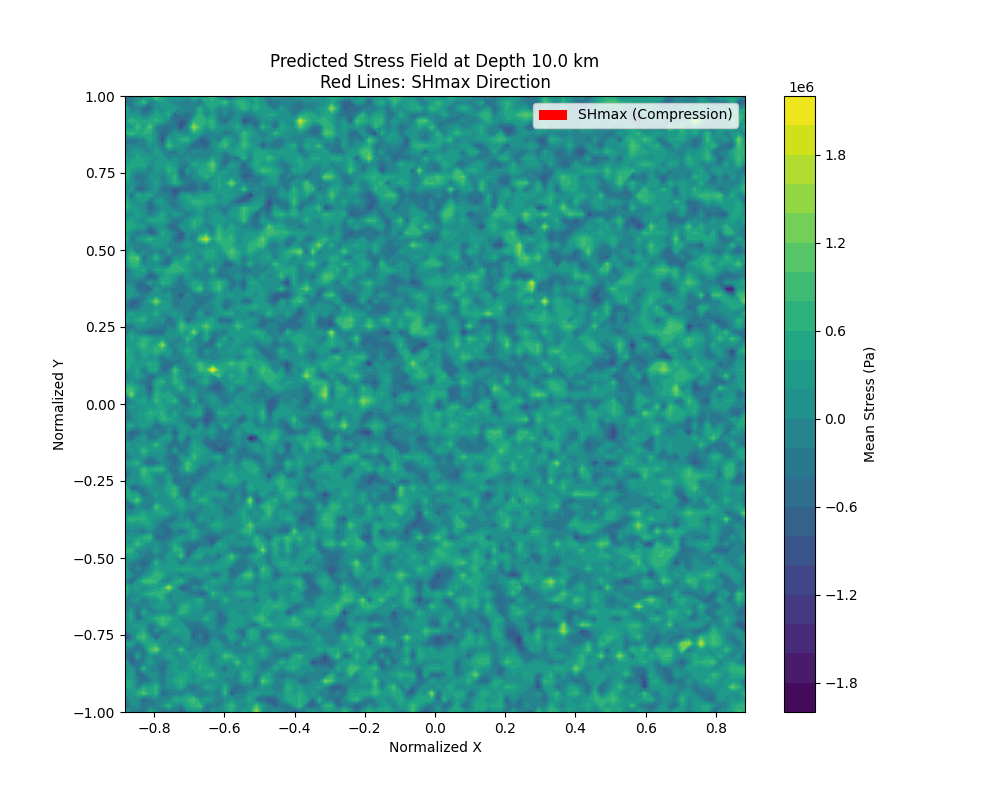

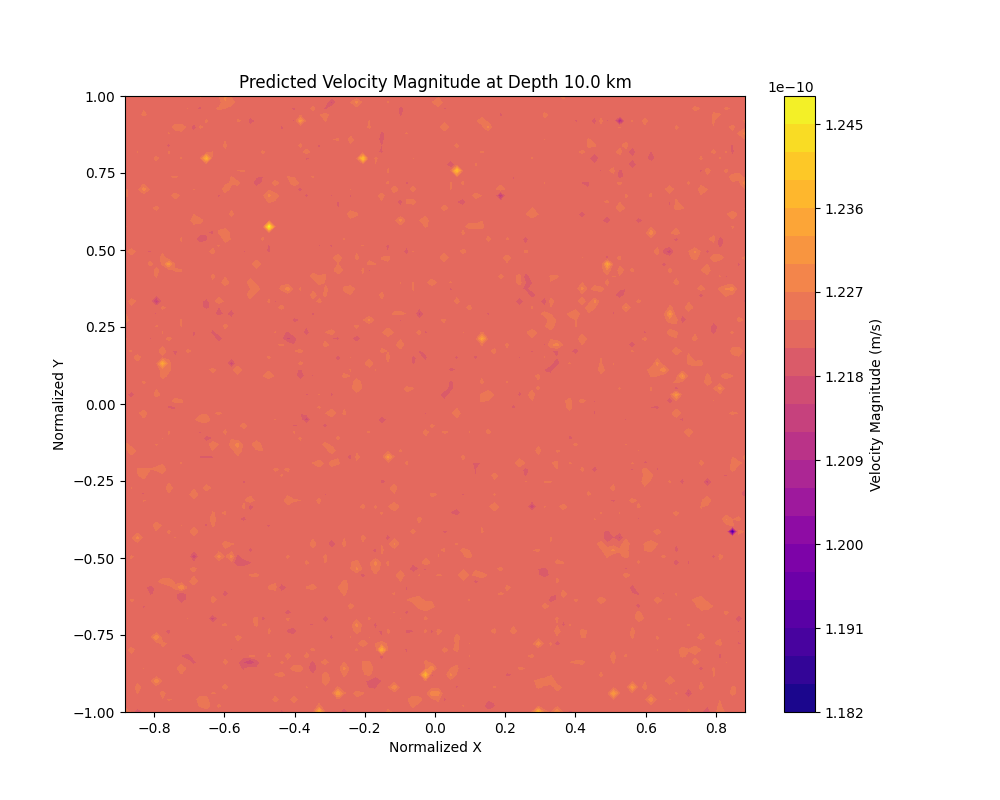

In [44]:
from IPython.display import Image, display
import os
for f in ['results/figs/stress_map_10km.png', 'results/figs/velocity_map_10km.png']:
    if os.path.exists(f): display(Image(f))

In [45]:
# Pack Everything for Download/Active Storage
!zip -r results_archive.zip results/ checkpoints/final_model.pth
try:
  from google.colab import files
  files.download('results_archive.zip')
except ImportError:
  print('Not running on Google Colab, skipping download.')

  adding: results/ (stored 0%)
  adding: results/figs/ (stored 0%)
  adding: results/figs/stress_map_10km.png (deflated 2%)
  adding: results/figs/velocity_map_10km.png (deflated 7%)
  adding: results/tables/ (stored 0%)
  adding: results/tables/best_params.json (deflated 30%)
  adding: results/tables/optuna_tuning_results.csv (deflated 59%)
  adding: checkpoints/final_model.pth (deflated 8%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [47]:
try:
  from google.colab import files
  files.download('results_archive.zip')
except ImportError:
  print('Not running on Google Colab, skipping download.')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>